In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.layers import Dropout,Dense,Flatten,Conv2D,MaxPool2D,Input
from keras.utils import to_categorical
from keras.datasets import cifar10

In [5]:
keras.__version__

'3.1.1'

In [6]:
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
tf.random.uniform([1])

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.6645621], dtype=float32)>

In [8]:
tf.random.uniform([1])

<tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.68789124], dtype=float32)>

In [9]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4299s 25us/step


In [10]:
print(cifar10.load_data.__doc__)

Loads the CIFAR10 dataset.

    This is a dataset of 50,000 32x32 color training images and 10,000 test
    images, labeled over 10 categories. See more info at the
    [CIFAR homepage](https://www.cs.toronto.edu/~kriz/cifar.html).

    The classes are:

    | Label | Description |
    |:-----:|-------------|
    |   0   | airplane    |
    |   1   | automobile  |
    |   2   | bird        |
    |   3   | cat         |
    |   4   | deer        |
    |   5   | dog         |
    |   6   | frog        |
    |   7   | horse       |
    |   8   | ship        |
    |   9   | truck       |

    Returns:
        Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

    **`x_train`**: `uint8` NumPy array of grayscale image data with shapes
      `(50000, 32, 32, 3)`, containing the training data. Pixel values range
      from 0 to 255.

    **`y_train`**: `uint8` NumPy array of labels (integers in range 0-9)
      with shape `(50000, 1)` for the training data.

    **`x_test`**: `uin

In [11]:
class_name = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

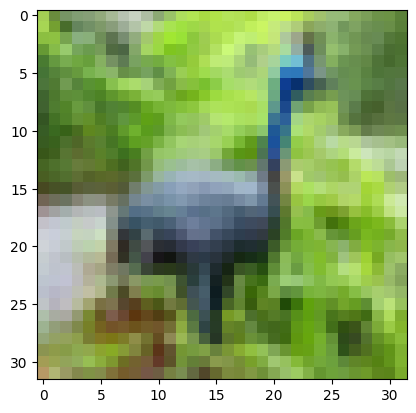

bird


In [12]:
index = 6
plt.imshow(X_train[index],cmap='gray')
plt.show()
print(class_name[y_train[index][0]])

In [13]:
X_train.shape

(50000, 32, 32, 3)

In [14]:
y_train.shape

(50000, 1)

In [15]:
X_test.shape

(10000, 32, 32, 3)

In [16]:
y_test.shape

(10000, 1)

In [17]:
X_test.max()

255

In [18]:
X_train = X_train / 255
X_test = X_test / 255

In [19]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [20]:
reg = keras.regularizers.l2(0.0003)

In [21]:
# model architecture >>> Sequential
model = keras.models.Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',
                 kernel_regularizer=reg,name='conv1'))
model.add(Dropout(0.25,name = 'drop1'))
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv2'))
model.add(Dropout(0.25,name = 'drop2'))
model.add(MaxPool2D(name='pool1'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv3'))
model.add(Dropout(0.25,name = 'drop3'))
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv4'))
model.add(Dropout(0.25,name = 'drop4'))
model.add(MaxPool2D(name='pool2'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv5'))
model.add(Dropout(0.25,name = 'drop5'))
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=1,padding='same',activation='relu',kernel_regularizer=reg,name='conv6'))
model.add(Dropout(0.25,name = 'drop6'))
model.add(Flatten(name='flatten'))
model.add(Dense(units=512,activation='relu',name = 'hidden1',kernel_regularizer=reg))
model.add(Dropout(0.5,name = 'drop7'))
model.add(Dense(units=10,activation='softmax',kernel_regularizer=reg ,name = 'output'))

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model.compile(optimizer=opt,loss=loss,metrics=[metric])

In [24]:
model.fit(X_train,y_train,epochs=10,batch_size=100,validation_split=0.2,verbose=2)

Epoch 1/10
400/400 - 325s - 812ms/step - categorical_accuracy: 0.3397 - loss: 1.9187 - val_categorical_accuracy: 0.4612 - val_loss: 1.6398
Epoch 2/10
400/400 - 168s - 420ms/step - categorical_accuracy: 0.4963 - loss: 1.5163 - val_categorical_accuracy: 0.5614 - val_loss: 1.4268
Epoch 3/10
400/400 - 211s - 528ms/step - categorical_accuracy: 0.5703 - loss: 1.3517 - val_categorical_accuracy: 0.6127 - val_loss: 1.2818
Epoch 4/10
400/400 - 161s - 402ms/step - categorical_accuracy: 0.6174 - loss: 1.2556 - val_categorical_accuracy: 0.6547 - val_loss: 1.2072
Epoch 5/10
400/400 - 251s - 627ms/step - categorical_accuracy: 0.6484 - loss: 1.1873 - val_categorical_accuracy: 0.6812 - val_loss: 1.1510
Epoch 6/10
400/400 - 151s - 377ms/step - categorical_accuracy: 0.6747 - loss: 1.1324 - val_categorical_accuracy: 0.6996 - val_loss: 1.1090
Epoch 7/10
400/400 - 147s - 368ms/step - categorical_accuracy: 0.6933 - loss: 1.0985 - val_categorical_accuracy: 0.6992 - val_loss: 1.1212
Epoch 8/10
400/400 - 138s -

In [25]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - categorical_accuracy: 0.7450 - loss: 1.0015


[1.007807970046997, 0.7421000003814697]

In [26]:
# keras functional api

In [27]:
reg = keras.regularizers.l2(0.0003)

In [28]:
# model architecture >>> Functional api
from keras.models import Model

# Define input layer
inputs = Input(shape=(32, 32, 3), name='input_layer')

# Block 1
block1 = Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv1')(inputs)
block1 = Dropout(0.25, name='drop1')(block1)
block1 = Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv2')(block1)
block1 = Dropout(0.25, name='drop2')(block1)
block1 = MaxPool2D(name='pool1')(block1)

# Block 2
block2 = Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv3')(block1)
block2 = Dropout(0.25, name='drop3')(block2)
block2 = Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv4')(block2)
block2 = Dropout(0.25, name='drop4')(block2)
block2 = MaxPool2D(name='pool2')(block2)

# Block 3
block3 = Conv2D(filters=128, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv5')(block2)
block3 = Dropout(0.25, name='drop5')(block3)
block3 = Conv2D(filters=128, kernel_size=(3,3), strides=1, padding='same', activation='relu', kernel_regularizer=reg, name='conv6')(block3)
block3 = Dropout(0.25, name='drop6')(block3)

# Classification layer
flattened = Flatten(name='flatten')(block3)
hidden_layer = Dense(units=512, activation='relu', kernel_regularizer=reg, name='hidden1')(flattened)
hidden_layer = Dropout(0.5, name='drop7')(hidden_layer)
outputs = Dense(units=10, activation='softmax', kernel_regularizer=reg, name='output')(hidden_layer)

# Define model
model_functional = Model(inputs=inputs, outputs=outputs)

In [29]:
model_functional.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop5 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden1 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,486,954 (17.12 MB)

 Trainable params: 4,486,954 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#compile model
opt = tf.optimizers.Adam(learning_rate=0.001)
loss = tf.losses.CategoricalCrossentropy()
metric = tf.metrics.CategoricalAccuracy()
model_functional.compile(optimizer=opt,loss=loss,metrics=[metric])

In [31]:
model_functional.fit(X_train,y_train,epochs=10,batch_size=100,validation_split=0.2,verbose=2)

Epoch 1/10
400/400 - 3884s - 10s/step - categorical_accuracy: 0.3503 - loss: 1.9139 - val_categorical_accuracy: 0.4869 - val_loss: 1.6152
Epoch 2/10
400/400 - 89s - 223ms/step - categorical_accuracy: 0.5065 - loss: 1.5011 - val_categorical_accuracy: 0.5775 - val_loss: 1.3628
Epoch 3/10
400/400 - 97s - 241ms/step - categorical_accuracy: 0.5879 - loss: 1.3317 - val_categorical_accuracy: 0.6193 - val_loss: 1.2845
Epoch 4/10
400/400 - 108s - 269ms/step - categorical_accuracy: 0.6306 - loss: 1.2368 - val_categorical_accuracy: 0.6848 - val_loss: 1.1416
Epoch 5/10
400/400 - 138s - 345ms/step - categorical_accuracy: 0.6590 - loss: 1.1741 - val_categorical_accuracy: 0.6797 - val_loss: 1.1528
Epoch 6/10
400/400 - 144s - 360ms/step - categorical_accuracy: 0.6810 - loss: 1.1269 - val_categorical_accuracy: 0.6898 - val_loss: 1.1478
Epoch 7/10
400/400 - 162s - 406ms/step - categorical_accuracy: 0.6975 - loss: 1.0921 - val_categorical_accuracy: 0.7084 - val_loss: 1.0824
Epoch 8/10
400/400 - 150s - 37

In [32]:
model_functional.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - categorical_accuracy: 0.7415 - loss: 1.0259


[1.0325276851654053, 0.7386999726295471]